<a href="https://colab.research.google.com/github/AlisonCarv/classificacao-cafe-efficientnet/blob/main/notebook_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Grãos de Café com EfficientNetB0 e Fine-Tuning

Projeto final da disciplina de Processamento de Imagens.

Dataset: Coffee Bean Dataset 224x224.

Classes: Dark, Green, Light e Medium.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import subprocess

REPO_URL = "https://github.com/AlisonCarv/classificacao-cafe-efficientnet.git"
REPO_DIR = "/content/classificacao-cafe-efficientnet"

if os.path.exists(REPO_DIR):
    print("Repositório já existe no Colab. Atualizando...")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    print("Clonando repositório...")
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print("Diretório atual:", os.getcwd())

Clonando repositório...
Diretório atual: /content/classificacao-cafe-efficientnet


In [3]:
!pip install -q -r requirements.txt

In [4]:
!mkdir -p outputs/checkpoints
!mkdir -p outputs/modelos
!mkdir -p outputs/logs
!mkdir -p outputs/figuras
!mkdir -p outputs/metricas

In [5]:
!ls "/content/drive/MyDrive/Colab Notebooks/Kaggle Coffee Bean Dataset"
!ls "/content/drive/MyDrive/Colab Notebooks/Kaggle Coffee Bean Dataset/train"
!ls "/content/drive/MyDrive/Colab Notebooks/Kaggle Coffee Bean Dataset/test"

'Coffee Bean.csv'   test   train
Dark  Green  Light  Medium
Dark  Green  Light  Medium


In [6]:
from src import config

from src.dados import (
    exibir_resumo_csv,
    carregar_datasets
)

from src.modelo import (
    criar_modelo,
    preparar_fine_tuning
)

from src.treino import (
    criar_callbacks,
    compilar_modelo,
    treinar_fase_1,
    treinar_fase_2,
    salvar_modelo
)

from src.visualizacao import (
    plotar_amostras_dataset,
    plotar_historico
)

from src.avaliacao import avaliar_modelo

In [7]:
df_dataset = exibir_resumo_csv()

Dimensão do CSV: (1600, 4)

Colunas:
['class index', 'filepaths', 'labels', 'data set']

Primeiras linhas:
   class index                  filepaths labels data set
0            0    train/Dark/dark (1).png   Dark    train
1            0   train/Dark/dark (10).png   Dark    train
2            0  train/Dark/dark (100).png   Dark    train
3            0  train/Dark/dark (101).png   Dark    train
4            0  train/Dark/dark (102).png   Dark    train


In [8]:
train_ds, val_ds, test_ds, class_names = carregar_datasets()

num_classes = len(class_names)

print("Classes:", class_names)
print("Número de classes:", num_classes)

Found 1200 files belonging to 4 classes.
Using 960 files for training.
Found 1200 files belonging to 4 classes.
Using 240 files for validation.
Found 400 files belonging to 4 classes.
Classes: ['Dark', 'Green', 'Light', 'Medium']
Número de classes: 4


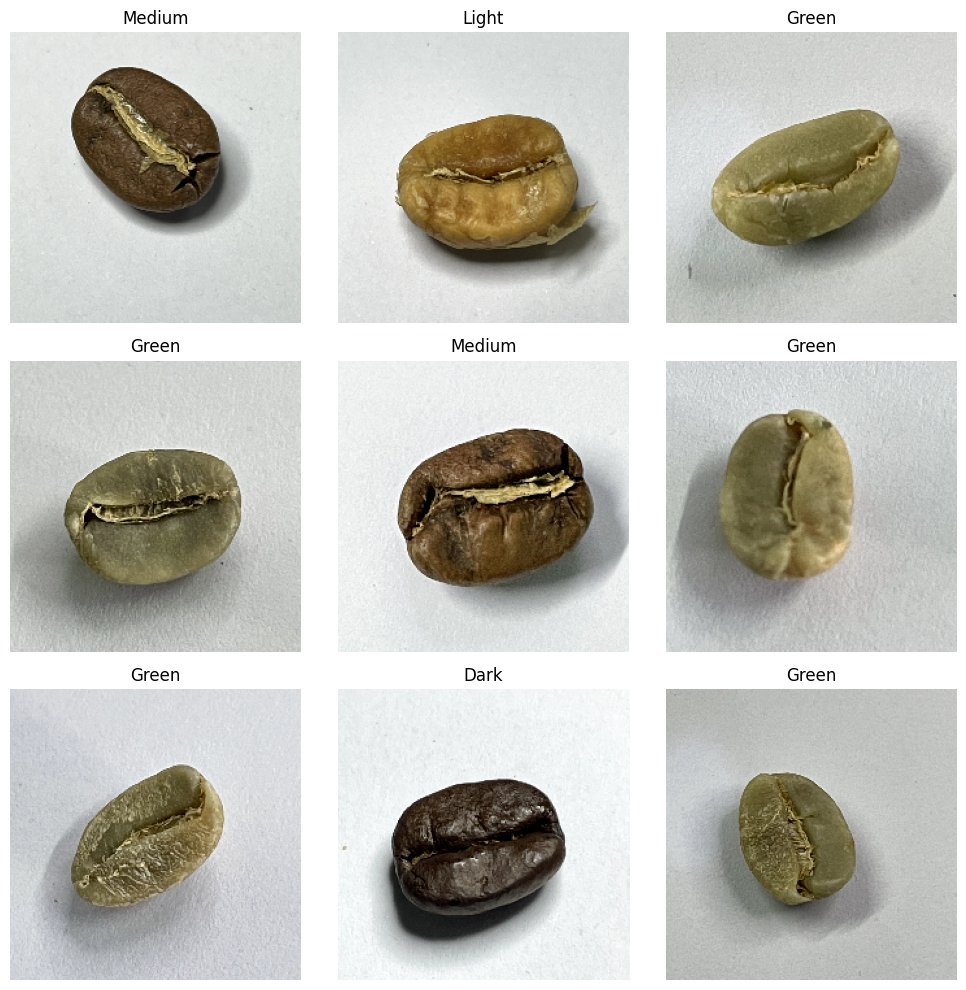

Amostras salvas em: outputs/figuras/amostras_dataset.png


In [9]:
plotar_amostras_dataset(train_ds, class_names)

In [10]:
modelo, modelo_base = criar_modelo(num_classes)
modelo.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_CoffeeBean"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_imagem (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento_dados (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_global                  │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacao_batch              │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida_softmax (Dense)           │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [11]:
callbacks = criar_callbacks()

In [12]:
modelo = compilar_modelo(
    modelo,
    learning_rate=config.LR_FASE_1
)

modelo, historico_fase_1 = treinar_fase_1(
    modelo,
    train_ds,
    val_ds,
    callbacks
)


Iniciando fase 1: transfer learning com EfficientNetB0 congelada.

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6479 - loss: 1.2169
Epoch 1: val_accuracy improved from None to 0.69167, saving model to outputs/checkpoints/efficientnetb0_best.weights.h5

Epoch 1: finished saving model to outputs/checkpoints/efficientnetb0_best.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7969 - loss: 0.7870 - val_accuracy: 0.6917 - val_loss: 0.8397 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9524 - loss: 0.3607
Epoch 2: val_accuracy improved from 0.69167 to 0.78333, saving model to outputs/checkpoints/efficientnetb0_best.weights.h5

Epoch 2: finished saving model to outputs/checkpoints/efficientnetb0_best.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9500 - loss: 0.3713 - val_accuracy: 0.7833 - val_loss: 0.7207 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.94

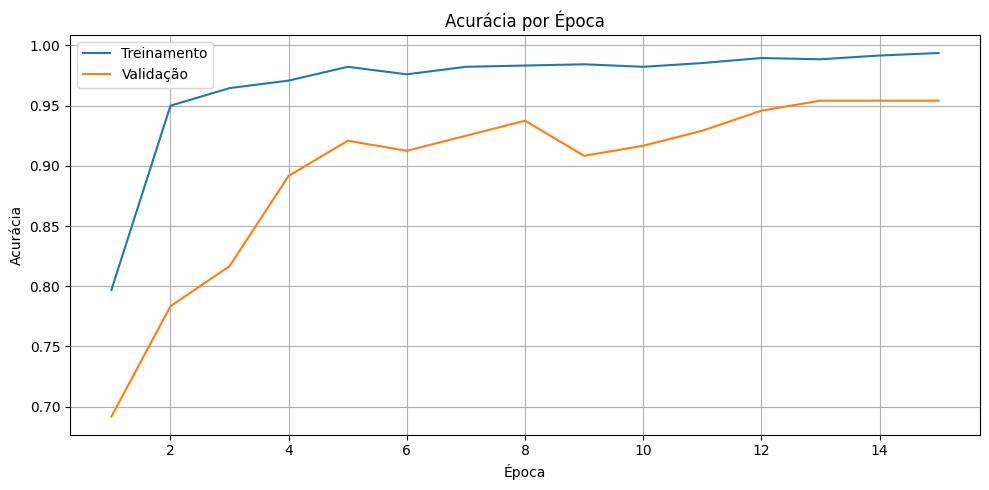

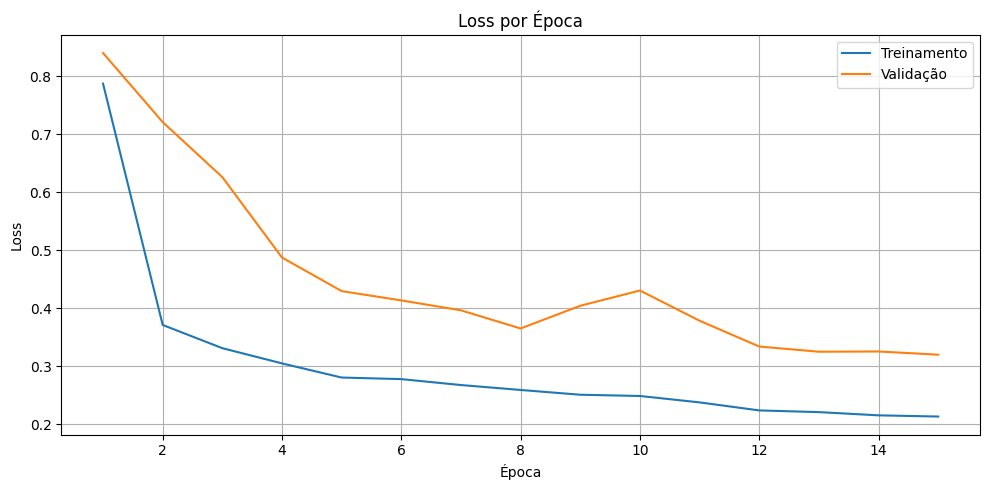

Histórico salvo em: outputs/figuras/fase_1_acuracia.png e outputs/figuras/fase_1_loss.png


In [13]:
plotar_historico(historico_fase_1, "fase_1")

In [14]:
preparar_fine_tuning(
    modelo_base,
    num_camadas_liberadas=config.NUM_CAMADAS_FINE_TUNING
)

Fine-tuning ativado nas últimas 30 camadas.


In [15]:
modelo = compilar_modelo(
    modelo,
    learning_rate=config.LR_FASE_2
)

modelo, historico_fase_2 = treinar_fase_2(
    modelo,
    train_ds,
    val_ds,
    callbacks
)


Iniciando fase 2: fine-tuning das últimas camadas da EfficientNetB0.

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8906 - loss: 0.4687
Epoch 1: val_accuracy did not improve from 0.95417
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 204ms/step - accuracy: 0.9052 - loss: 0.4379 - val_accuracy: 0.9417 - val_loss: 0.3544 - learning_rate: 1.0000e-05
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9042 - loss: 0.4845
Epoch 2: val_accuracy did not improve from 0.95417

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9250 - loss: 0.4192 - val_accuracy: 0.9458 - val_loss: 0.3426 - learning_rate: 1.0000e-05
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9181 - loss: 0.3907
Epoch 3: val_accuracy did not improve from 0.95417
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9208 - loss: 0.3794 - val_accuracy: 0.9458 - val_loss: 0.3140 - learning_rate: 3.0000e-06
Epoch 4

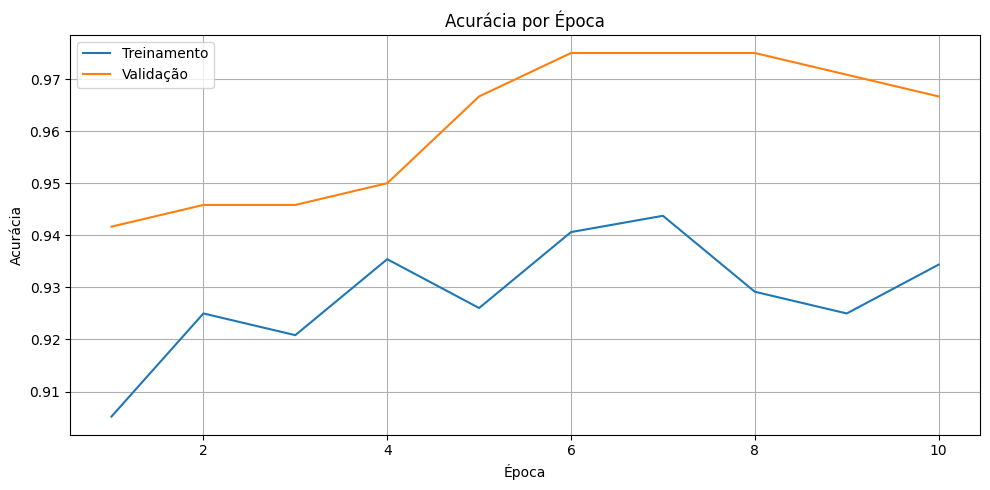

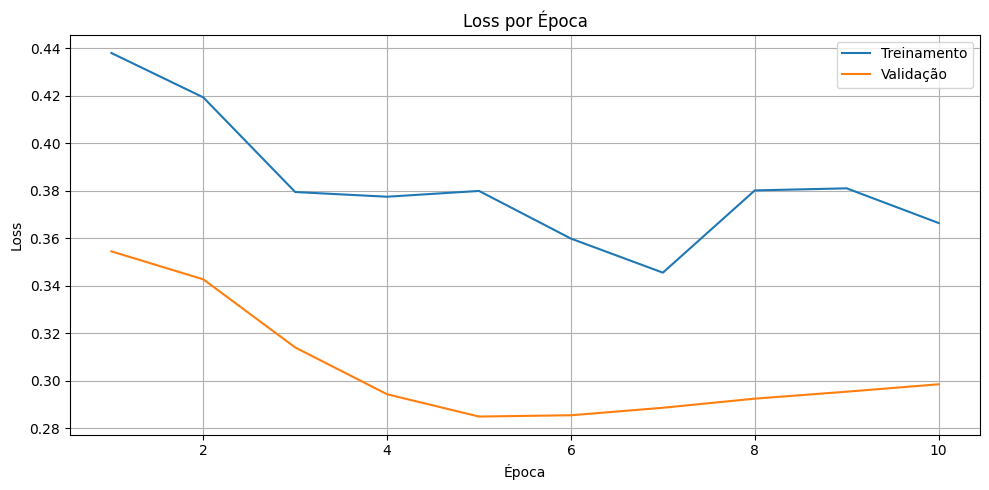

Histórico salvo em: outputs/figuras/fase_2_acuracia.png e outputs/figuras/fase_2_loss.png


In [16]:
plotar_historico(historico_fase_2, "fase_2")

In [17]:
salvar_modelo(modelo)


Modelo salvo em: outputs/modelos/efficientnetb0_coffee.keras



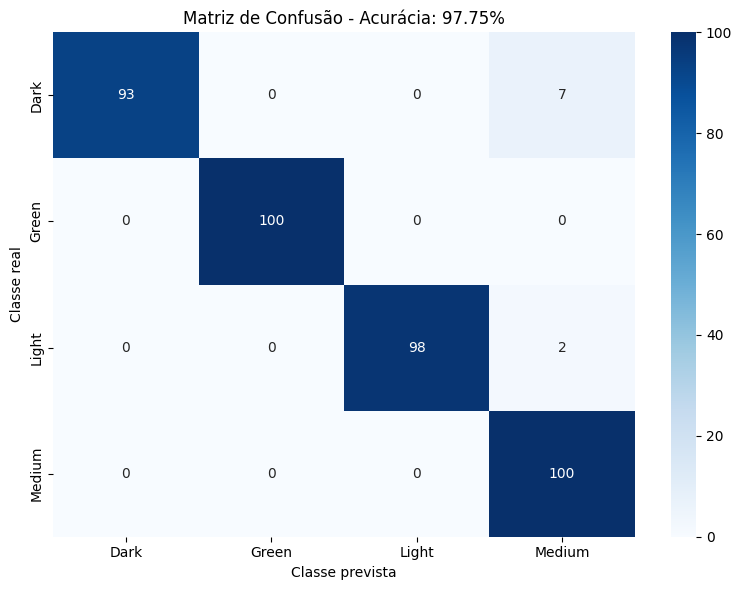

Matriz de confusão salva em: outputs/figuras/matriz_confusao.png


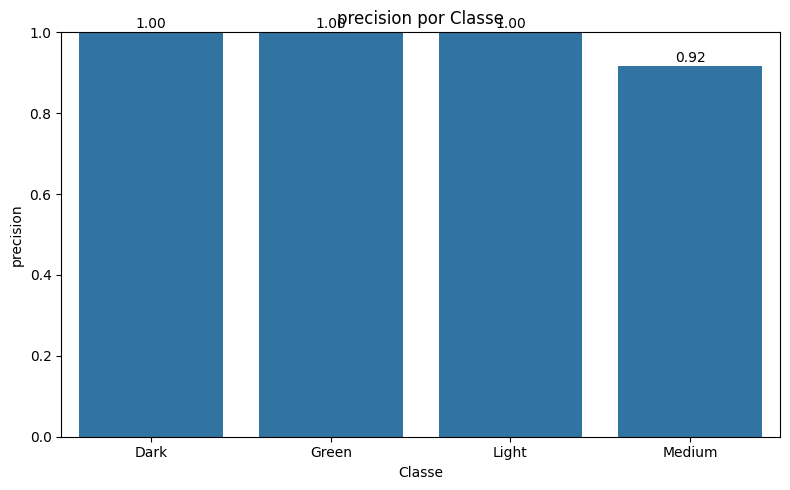

Gráfico salvo em: outputs/figuras/precision.png


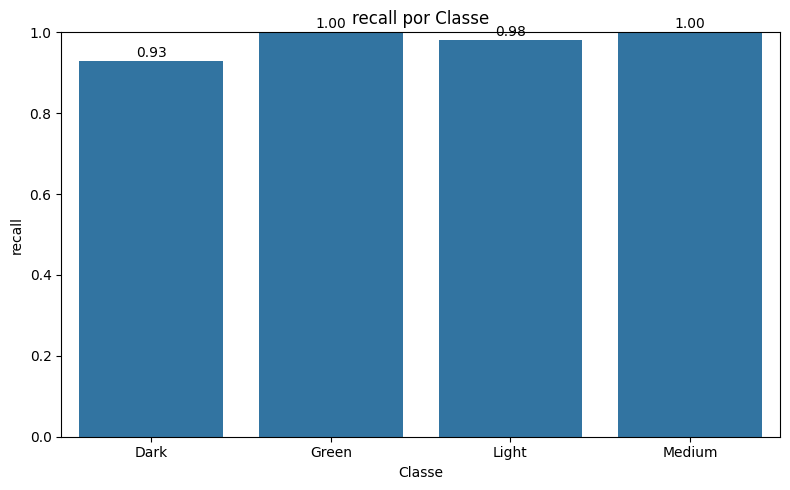

Gráfico salvo em: outputs/figuras/recall.png


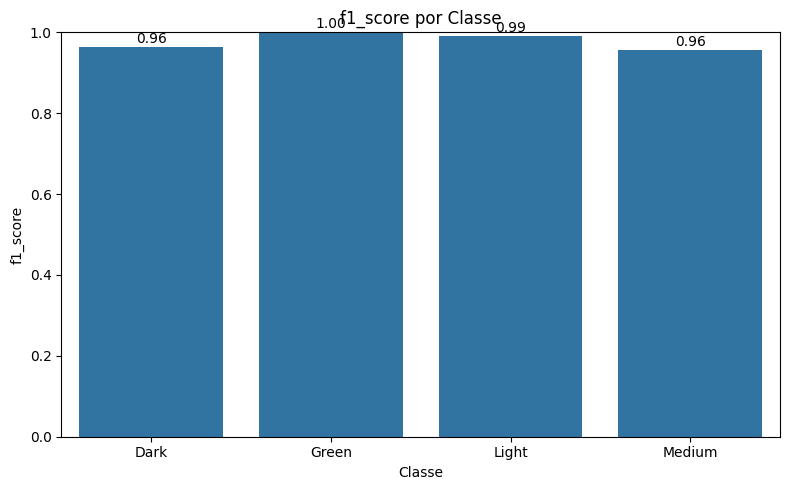

Gráfico salvo em: outputs/figuras/f1_score.png

Relatório de classificação:

Acurácia: 0.9775

              precision    recall  f1-score   support

        Dark     1.0000    0.9300    0.9637       100
       Green     1.0000    1.0000    1.0000       100
       Light     1.0000    0.9800    0.9899       100
      Medium     0.9174    1.0000    0.9569       100

    accuracy                         0.9775       400
   macro avg     0.9794    0.9775    0.9776       400
weighted avg     0.9794    0.9775    0.9776       400

Relatório salvo em: outputs/metricas/relatorio_classificacao.txt
Acurácia final no teste: 0.9775


In [18]:
acuracia_final = avaliar_modelo(
    modelo,
    test_ds,
    class_names
)

print(f"Acurácia final no teste: {acuracia_final:.4f}")

In [19]:
!zip -r resultados_outputs.zip outputs/figuras outputs/metricas outputs/logs

  adding: outputs/figuras/ (stored 0%)
  adding: outputs/figuras/f1_score.png (deflated 32%)
  adding: outputs/figuras/fase_2_loss.png (deflated 16%)
  adding: outputs/figuras/fase_2_acuracia.png (deflated 15%)
  adding: outputs/figuras/precision.png (deflated 32%)
  adding: outputs/figuras/fase_1_acuracia.png (deflated 17%)
  adding: outputs/figuras/matriz_confusao.png (deflated 23%)
  adding: outputs/figuras/fase_1_loss.png (deflated 16%)
  adding: outputs/figuras/amostras_dataset.png (deflated 6%)
  adding: outputs/figuras/recall.png (deflated 33%)
  adding: outputs/metricas/ (stored 0%)
  adding: outputs/metricas/relatorio_classificacao.txt (deflated 61%)
  adding: outputs/logs/ (stored 0%)
  adding: outputs/logs/historico_treinamento.csv (deflated 58%)


In [20]:
from google.colab import files
files.download("resultados_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>